<a href="https://colab.research.google.com/gist/kimchi-chisung/596f1e9626d1a86746b32838c3323247/a10_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CEE6501 — Final Project


---
---

## Import helper function

In [2]:
from helpers.preprocess import *
from helpers.elements import *
from helpers.assembly import *
from helpers.partition import *
from helpers. solver import *
from helpers.postprocess import *
from helpers.fef import *
from helpers.releases import *

In [13]:
# ============================================================
# Select model
# ============================================================

# Validation Truss
# model_path = "inputs/validation_truss.json"

# Validation Frame
# model_path = "inputs/validation_frame_original.json"
# model_path = "inputs/validation_frame_moment_release.json"
# model_path = "inputs/validation_frame_prescribed_displacement.json"
# model_path = "inputs/validation_frame_temperature_loads.json"
# model_path = "inputs/validation_frame_fabrication_error.json"

# Final Structure: Chaotianmen Bridge (3D_frame + 3D_truss + 3D_cable)
# model_path = "inputs/chaotianmen_bridge.json"
# model_path = "inputs/chaotianmen_dead_road_train.json"
model_path = "inputs/chaotianmen_all.json"
# model_path = "inputs/chaotianmen_input_updated.json"

model = load_model(model_path)
model_name = Path(model_path).stem

# ============================================================

nodes = model["nodes"]
elements = model["elements"]
supports = model["supports"]
nodal_loads = model["nodal_loads"]
prescribed_displacements = model["prescribed_displacements"]
member_loads = model["member_loads"]
temperature_loads = model["temperature_loads"]
fabrication_errors = model["fabrication_errors"]
releases = model["releases"]

# ------------------------------------------------------------
# Global load / displacement vectors and restrained DOFs
# ------------------------------------------------------------
F_global = build_global_load_vector(nodes, nodal_loads)
u_global = build_global_displacement_vector(nodes, prescribed_displacements)
dof_restrained_1based = restrained_dofs_1based(supports, node_dofs_1based_6dof)

# ------------------------------------------------------------
# Build element-level data for mixed truss-frame-cable system
# ------------------------------------------------------------
k_list = []
T_list = []
Qf_list = []
map_list = []
Qf_debug = {}

for eid, elem in elements.items():
    i_node, j_node = elem["nodes"]
    l, m, n, L = element_csL(nodes[i_node], nodes[j_node])

    if elem["type"] in ["3D_truss", "3D_cable"]:
        k_local = truss_k_local_3d(elem["E"], elem["A"], L)
        T = truss_transformation_matrix_3d(l, m, n)
        Qf_local = np.zeros(6, dtype=float)
        dof_map = dof_map_truss_3d(i_node, j_node)

    elif elem["type"] == "3D_frame":
        k_local = frame_k_local_3d(
            elem["E"],
            elem["A"],
            elem["I"],
            elem["J"],
            L
        )
        T = frame_transformation_matrix_3d(l, m, n)
        
        Qf_local = build_Qf_local_from_loads(
            elem=elem,
            eid=eid,
            L=L,
            l=l,
            m=m,
            n=n,
            member_loads=member_loads,
            temperature_loads=temperature_loads,
            fabrication_errors=fabrication_errors
        )
            
        elem_releases = get_release_by_eid(releases, eid, default=[])
        if len(elem_releases) > 0:
            k_local, Qf_local = apply_frame_releases_local(
                k_local,
                Qf_local,
                elem_releases,
            )

        dof_map = dof_map_frame_3d(i_node, j_node)

    else:
        raise ValueError(f"Unknown element type: {elem['type']}")

    k_list.append(k_local)
    T_list.append(T)
    Qf_list.append(Qf_local)
    map_list.append(dof_map)
    Qf_debug[str(eid)] = Qf_local.copy()


# ------------------------------------------------------------
# Global assembly
# ------------------------------------------------------------
ndof = 6 * len(nodes)

K_global, F_fef_global = assemble_global_stiffness_and_fef(
    ndof,
    k_list,
    T_list,
    Qf_list,
    map_list,
)

# ------------------------------------------------------------
# Set fictitious restraints from releases
# ------------------------------------------------------------
dof_restrained_1based, dof_fictitious_1based = add_zero_stiffness_dofs_to_restrained(
    K_global,
    dof_restrained_1based,
)

# ------------------------------------------------------------
# Partition
# ------------------------------------------------------------
(
    K_ff,
    K_fr,
    K_rf,
    K_rr,
    f_f,
    f_r,
    u_r,
    f_fef_f,
    f_fef_r,
    free_dofs,
    restrained_dofs,
) = partition_system(
    K_global,
    F_global,
    u_global,
    F_fef_global,
    dof_restrained_1based,
)

# ------------------------------------------------------------
# Solve
# ------------------------------------------------------------
u_f = solve_free_displacements(
    K_ff,
    K_fr,
    f_f,
    u_r,
    f_fef_f,
)

F_r = compute_reactions(
    K_rf,
    K_rr,
    u_f,
    u_r,
    f_fef_r,
)

# ------------------------------------------------------------
# Reconstruct full global vectors
# ------------------------------------------------------------
u_global_complete = assemble_global_displacements(
    u_f,
    u_r,
    free_dofs,
    restrained_dofs,
)

f_global_complete = assemble_global_forces(
    f_f,
    F_r,
    free_dofs,
    restrained_dofs,
)

# ------------------------------------------------------------
# Basic output
# ------------------------------------------------------------
print("\nu_global_complete =")
print(u_global_complete * 1000)

print("\nf_global_complete =")
print(f_global_complete)

# ============================================================
# Element lengths
# ============================================================
element_lengths = {
    eid: element_csL(
        nodes[elem["nodes"][0]],
        nodes[elem["nodes"][1]]
    )[3]
    for eid, elem in elements.items()
}

# ============================================================
# Truss element results
# ============================================================
results_truss = {}

for eid, elem in elements.items():
    if elem["type"] != "3D_truss":
        continue

    i_node, j_node = elem["nodes"]
    l, m, n, L = element_csL(nodes[i_node], nodes[j_node])

    T = truss_transformation_matrix_3d(l, m, n)
    k_local = truss_k_local_3d(elem["E"], elem["A"], L)
    m_e = dof_map_truss_3d(i_node, j_node)

    u_g = u_global_complete[m_e - 1]
    u_l = truss_local_displacements_3d(T, u_g)
    q_l = truss_local_end_forces_3d(k_local, u_l)

    N = truss_axial_force_3d(q_l)
    sigma = N / elem["A"]

    results_truss[eid] = {
        "u_global": u_g,
        "u_local": u_l,
        "q_local": q_l,
        "N": N,
        "sigma": sigma,
    }

# ============================================================
# Cable element results
# ============================================================
results_cable = {}

for eid, elem in elements.items():
    if elem["type"] != "3D_cable":
        continue

    i_node, j_node = elem["nodes"]
    l, m, n, L = element_csL(nodes[i_node], nodes[j_node])

    T = truss_transformation_matrix_3d(l, m, n)
    k_local = truss_k_local_3d(elem["E"], elem["A"], L)
    m_e = dof_map_truss_3d(i_node, j_node)

    u_g = u_global_complete[m_e - 1]
    u_l = truss_local_displacements_3d(T, u_g)
    q_l = truss_local_end_forces_3d(k_local, u_l)

    N = truss_axial_force_3d(q_l)
    sigma = N / elem["A"]

    results_cable[eid] = {
        "u_global": u_g,
        "u_local": u_l,
        "q_local": q_l,
        "N": N,
        "sigma": sigma,
        "state": "tension" if N > 0 else "slack/compression" if N < 0 else "zero",
    }

# ============================================================
# Frame element results
# ============================================================
results_frame = {}

for eid, elem in elements.items():
    if elem["type"] != "3D_frame":
        continue

    i_node, j_node = elem["nodes"]
    l, m, n, L = element_csL(nodes[i_node], nodes[j_node])

    T = frame_transformation_matrix_3d(l, m, n)
    k_local = frame_k_local_3d(
        elem["E"],
        elem["A"],
        elem["I"],
        elem["J"],
        L
    )
    m_e = dof_map_frame_3d(i_node, j_node)
    
    Qf_local = build_Qf_local_from_loads(
        elem=elem,
        eid=eid,
        L=L,
        l=l,
        m=m,
        n=n,
        member_loads=member_loads,
        temperature_loads=temperature_loads,
        fabrication_errors=fabrication_errors
    )

    elem_releases = get_release_by_eid(releases, eid, default=[])
    if len(elem_releases) > 0:
        k_local, Qf_local = apply_frame_releases_local(
            k_local,
            Qf_local,
            elem_releases,
        )

    u_g = u_global_complete[m_e - 1]
    u_l = frame_local_displacements_3d(T, u_g)

    q_l_elastic = frame_local_end_forces_3d(k_local, u_l)
    q_l = q_l_elastic + Qf_local

    Mmax = max(abs(q_l[4]), abs(q_l[5]), abs(q_l[10]), abs(q_l[11]))
    N_axial = max(abs(q_l[0]), abs(q_l[6]))

    results_frame[eid] = {
        "u_global": u_g,
        "u_local": u_l,
        "q_local": q_l,
        "q_local_elastic": q_l_elastic,
        "Qf_local": Qf_local,
        "Mmax": Mmax,
        "N_axial": N_axial,
    }

tables = build_result_tables(
    elements=elements,
    element_lengths=element_lengths,
    results_truss=results_truss,
    results_cable=results_cable,
    results_frame=results_frame,
    display_tables=False,
    save_tables=True,
    save_dir="outputs",
    model_path=model_path,
    nodes=nodes,
    supports=supports,
    Qf_debug=Qf_debug,
    u_f=u_f,
    F_r=F_r,
    u_global_complete=u_global_complete,
    f_global_complete=f_global_complete,
    F_global=F_global,
    F_fef_global=F_fef_global,
    releases=releases,
)



u_global_complete =
[0. 0. 0. ... 0. 0. 0.]

f_global_complete =
[-1.07522254e+04  6.48020440e+00  4.27991027e+03 ...  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
Saved tables: outputs/chaotianmen_all/chaotianmen_all.xlsx


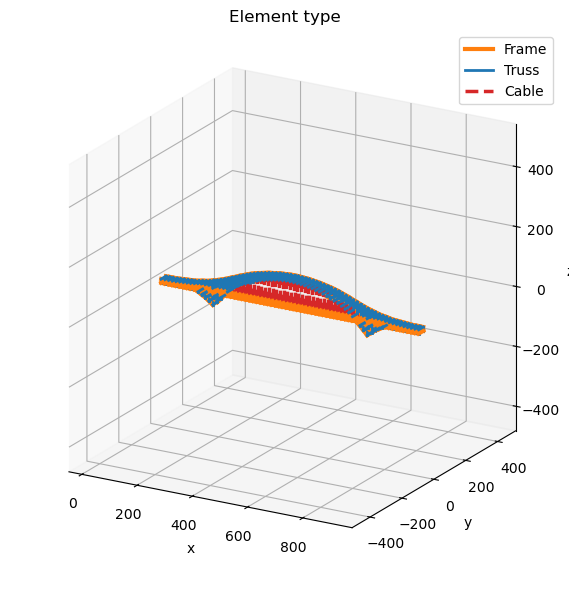

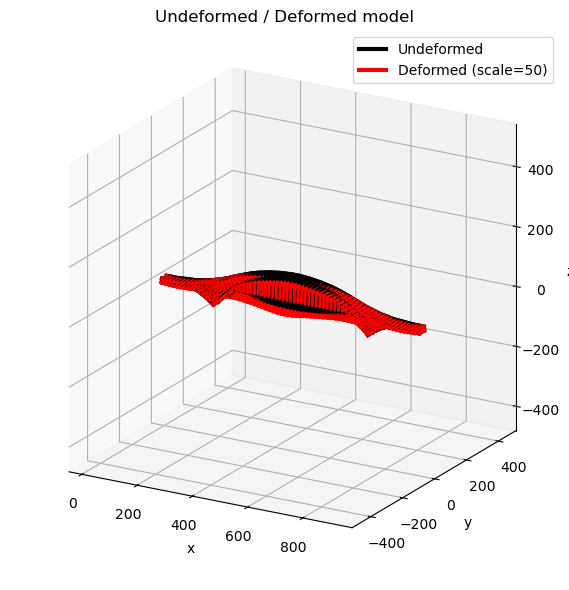

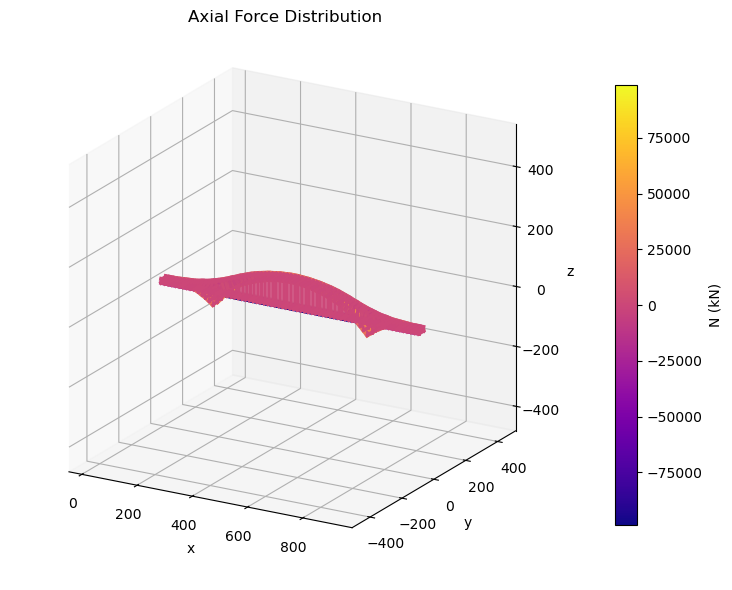

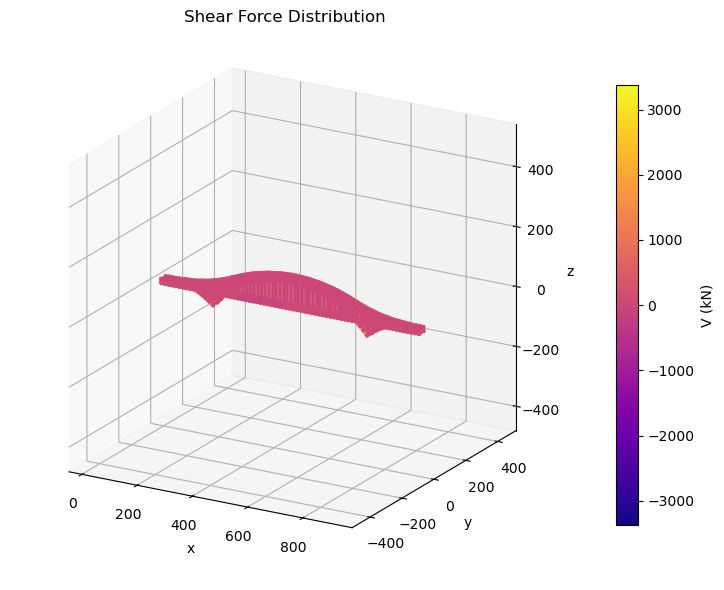

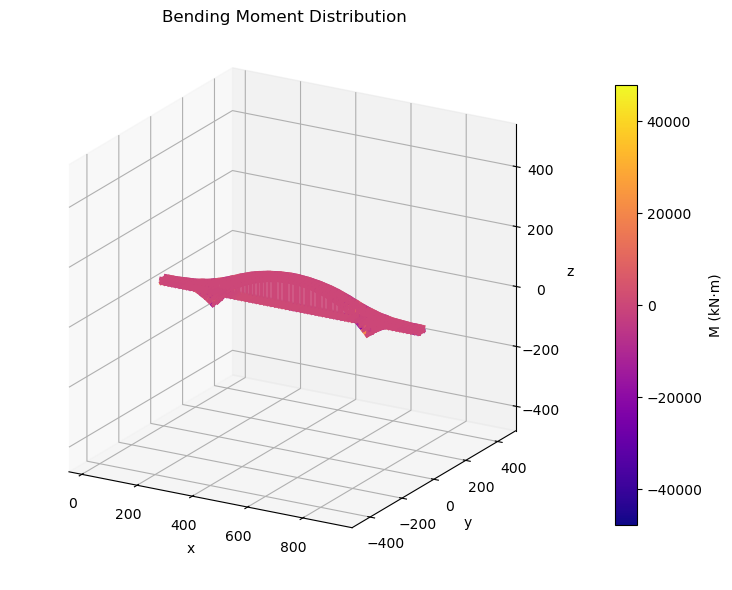

Saved Plotly HTML: outputs/chaotianmen_all/chaotianmen_all_plotly_3d.html


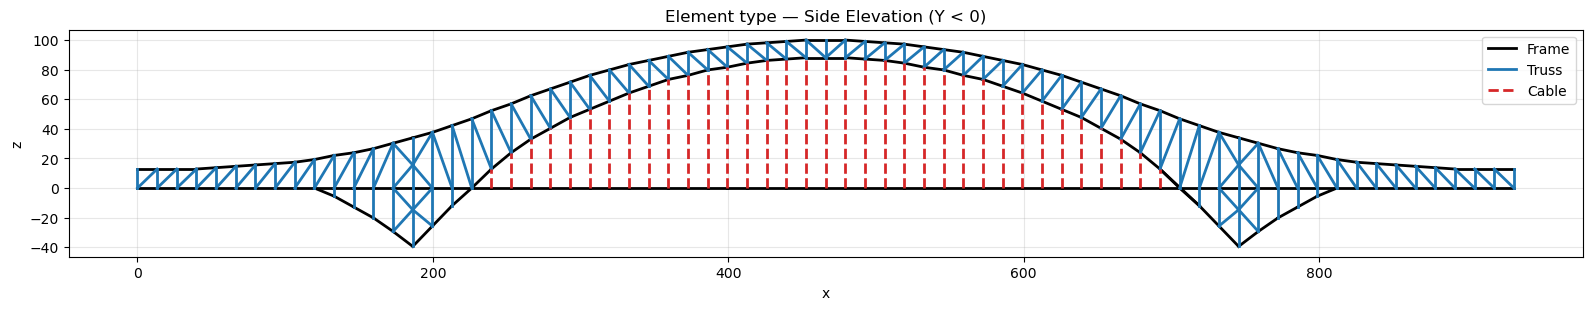

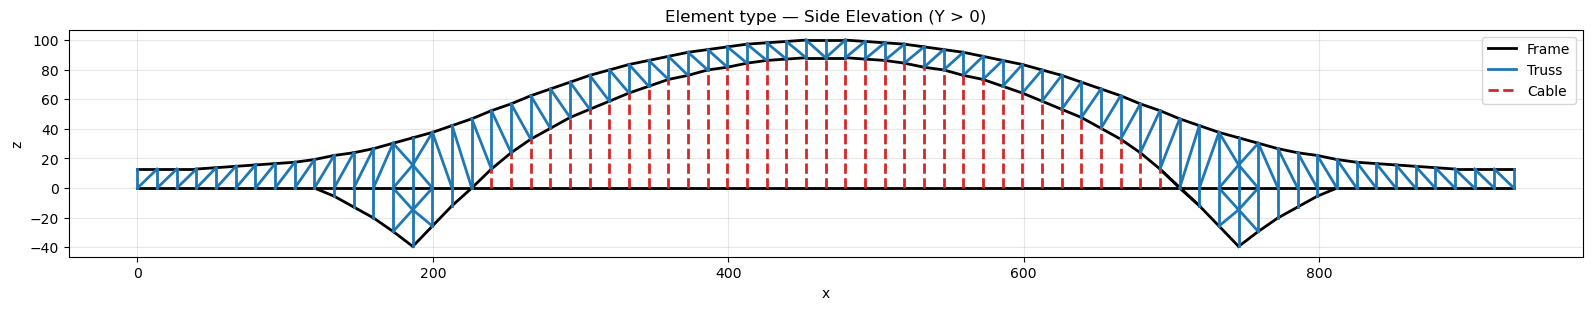

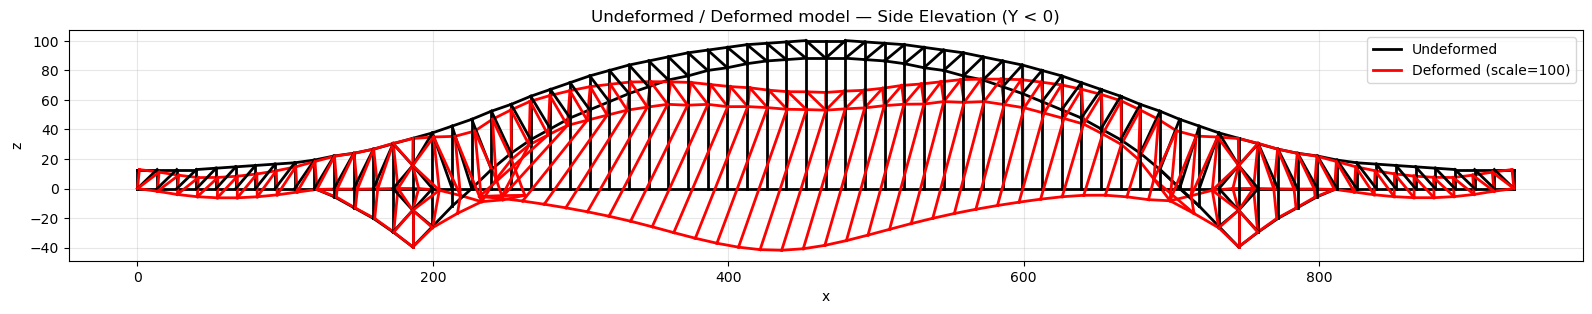

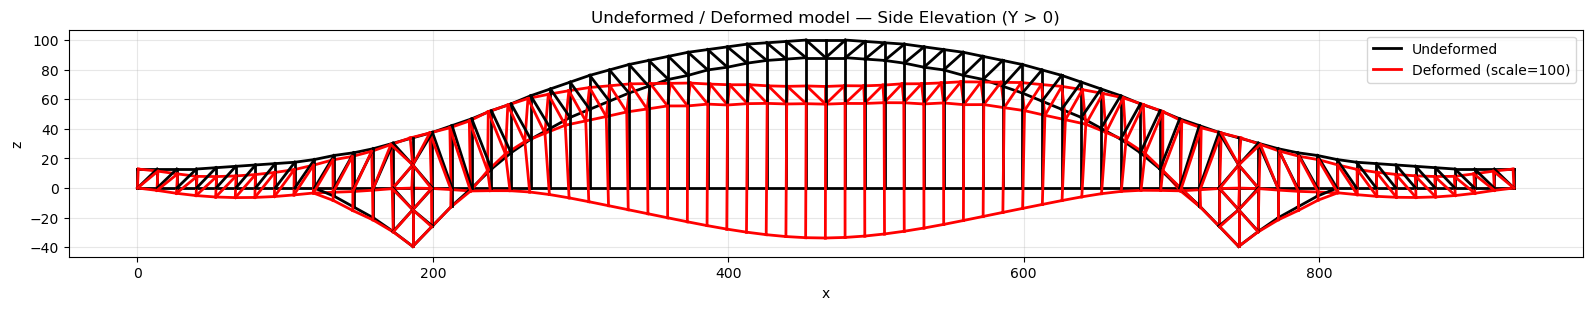

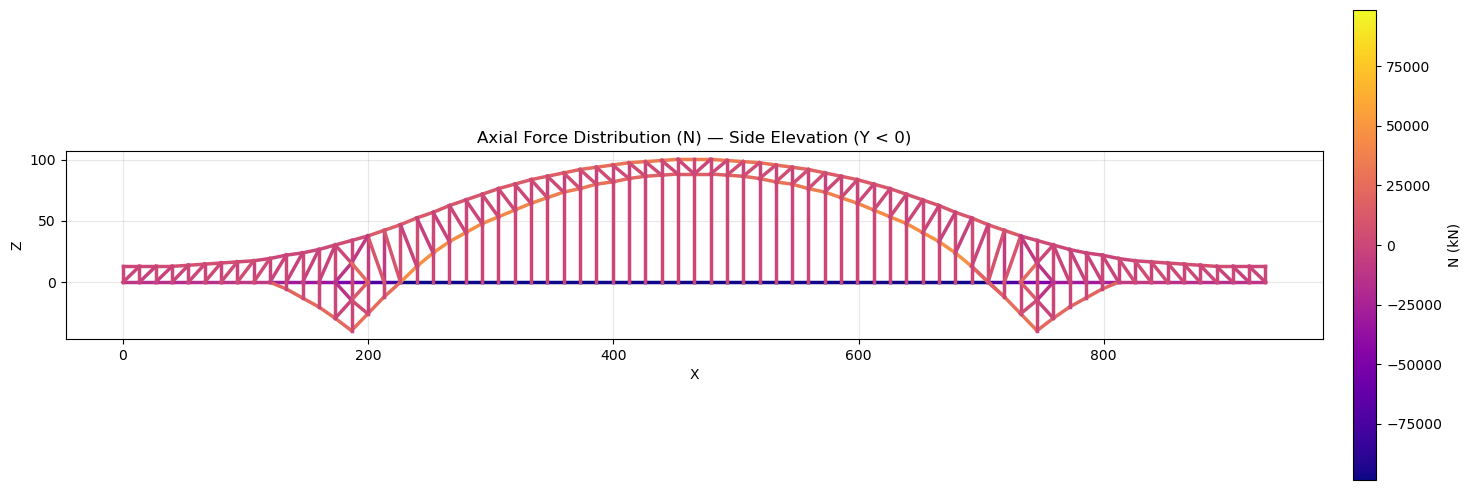

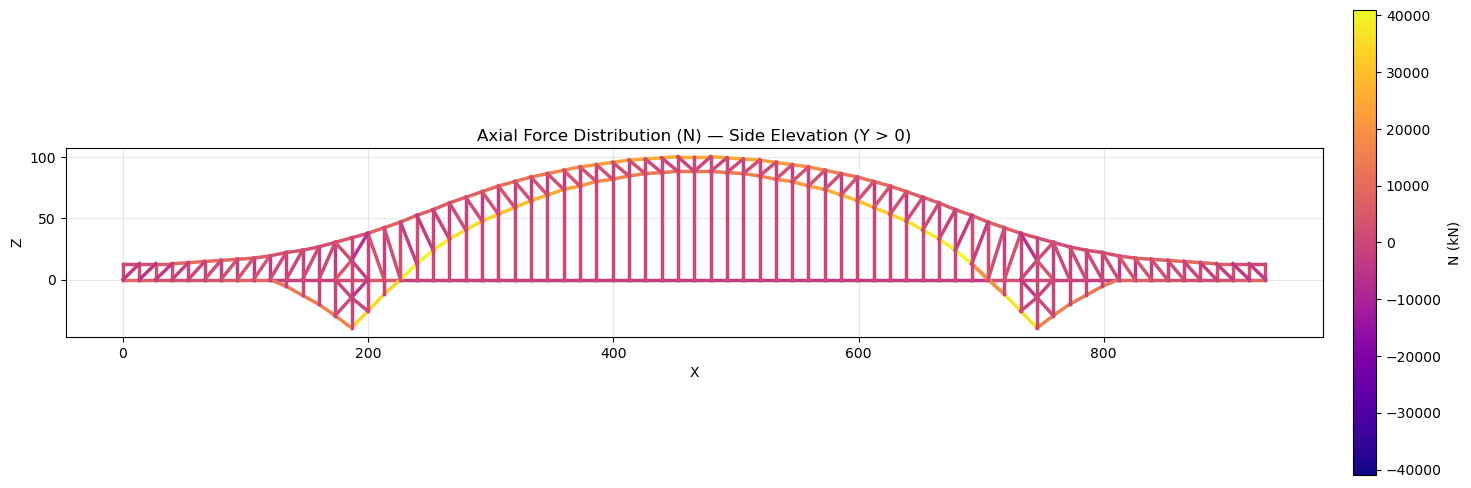

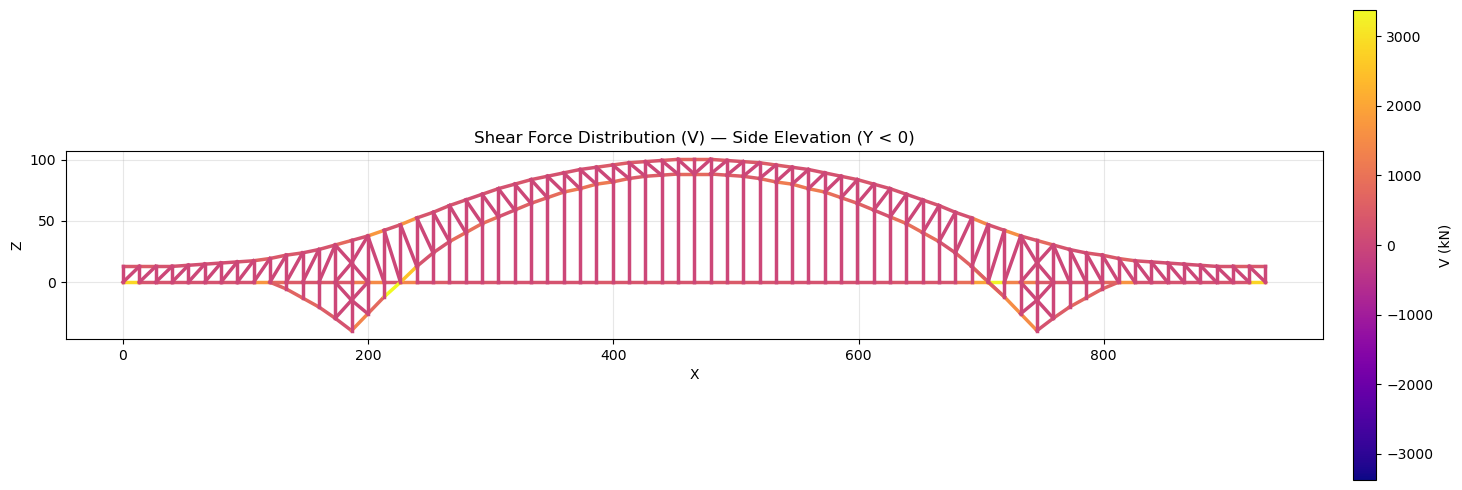

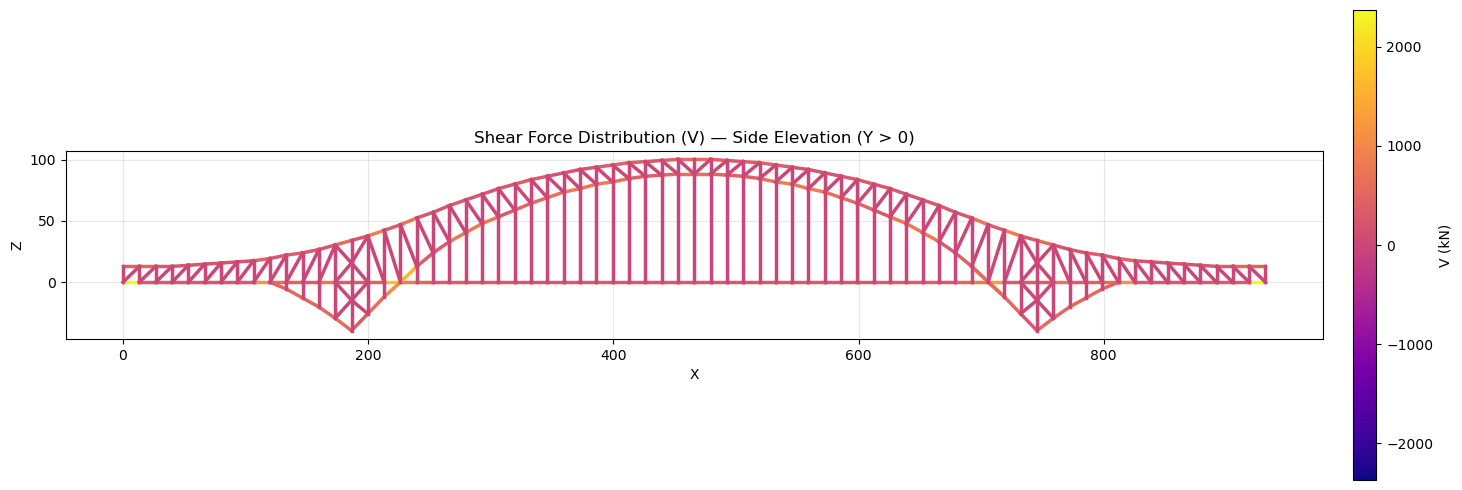

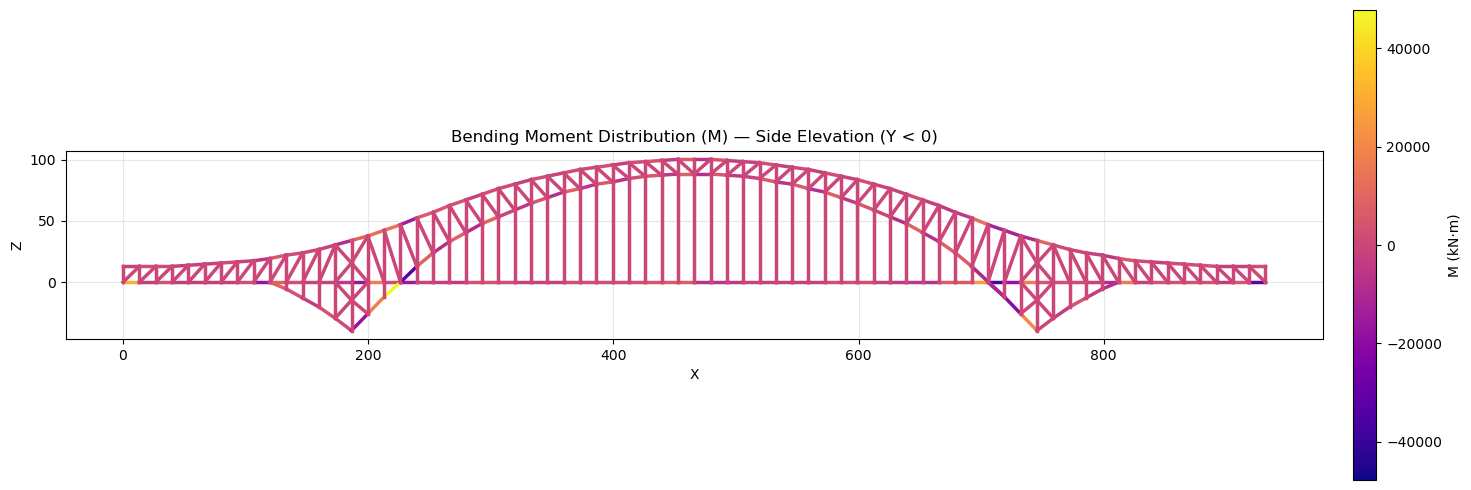

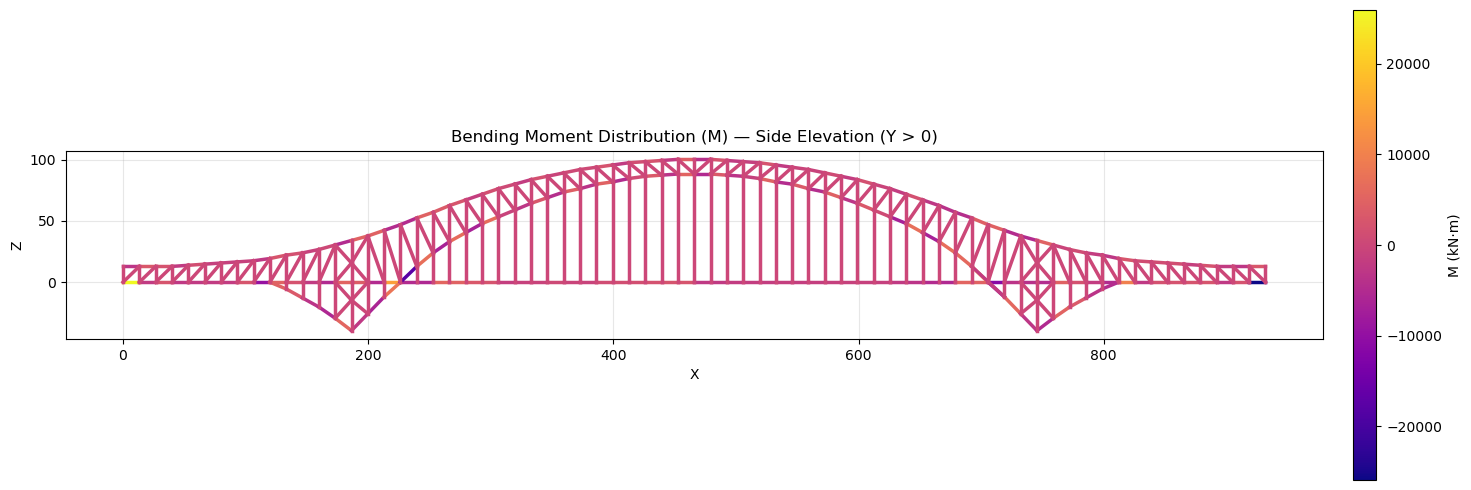

In [14]:
plot_results(
    nodes=nodes,
    elements=elements,
    u_global_complete=u_global_complete,
    results_truss=results_truss,
    results_cable=results_cable,
    results_frame=results_frame,
    supports=supports,
    nodal_loads=nodal_loads,
    display_3d=True,
    save_3d=True,
    display_2d=True,
    save_2d=True,
    model_path=model_path,
    split_by_y_plane_2d=True,
)